In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from option_pricing.models.heston import HestonParams
from option_pricing.pricers.heston import (
    heston_price_call_from_ctx,
    heston_price_put_from_ctx,
)
from option_pricing.types import MarketData
from option_pricing.vol.implied_vol_slice import implied_vol_black76_slice

# 1) Market + one fixed Heston parameter set
market = MarketData(spot=100.0, rate=0.02, dividend_yield=0.00)
ctx = market.to_context()
tau = 1.0

params = HestonParams(
    kappa=2.0,   # mean reversion
    vbar=0.04,   # long-run variance
    eta=0.55,    # vol of vol
    rho=-0.70,   # spot/variance correlation
    v=0.05,      # initial variance
)

# 2) Single maturity strike grid
strikes = np.linspace(70.0, 130.0, 25)

forward = float(ctx.fwd(tau))
df = float(ctx.df(tau))

call_prices = np.asarray(
    heston_price_call_from_ctx(
        strike=strikes,
        ctx=ctx,
        tau=tau,
        params=params,
    ),
    dtype=float,
)

put_prices = np.asarray(
    heston_price_put_from_ctx(
        strike=strikes,
        ctx=ctx,
        tau=tau,
        params=params,
    ),
    dtype=float,
)

implied_vols = implied_vol_black76_slice(
    forward=forward,
    strikes=strikes,
    tau=tau,
    df=df,
    prices=call_prices,
    is_call=True,
)

rows = [
    {
        "K": K,
        "log_moneyness": lm,
        "call_price": c,
        "put_price": p,
        "implied_vol": iv,
    }
    for K, lm, c, p, iv in zip(
        strikes,
        np.log(strikes / forward),
        call_prices,
        put_prices,
        implied_vols, strict=False,
    )
]
smile = pd.DataFrame(rows)
smile.head()

,K,log_moneyness,call_price,put_price,implied_vol
0,70.0,-0.376675,32.240291,0.854198,0.272446
1,72.5,-0.341584,29.977214,1.041617,0.265467
2,75.0,-0.307682,27.747325,1.262226,0.258549
3,77.5,-0.274892,25.555345,1.520742,0.251686
4,80.0,-0.243144,23.406553,1.822447,0.244876


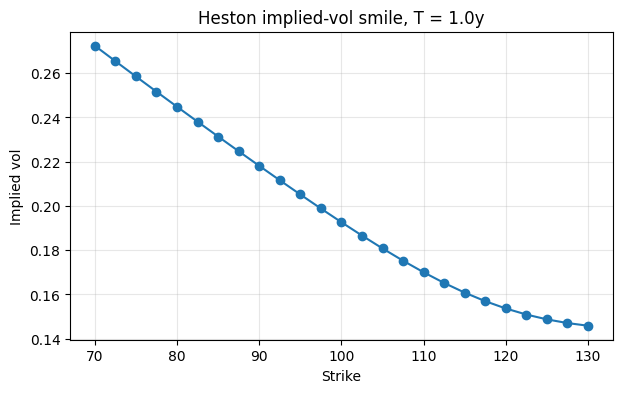

In [7]:
# 3) Plot the smile
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(smile["K"], smile["implied_vol"], marker="o")
ax.set_title("Heston implied-vol smile, T = 1.0y")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied vol")
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 4) Basic validation checks
parity_err = np.max(
    np.abs(
        (smile["call_price"] - smile["put_price"]).to_numpy()
        - df * (forward - smile["K"].to_numpy())
    )
)

is_call_monotone = np.all(np.diff(smile["call_price"].to_numpy()) <= 1e-8)
are_prices_nonnegative = np.all(smile["call_price"] >= -1e-12)

print("max put-call parity error:", parity_err)
print("call prices decreasing in strike:", is_call_monotone)
print("nonnegative prices:", are_prices_nonnegative)

assert call_prices.shape == strikes.shape
assert put_prices.shape == strikes.shape

max put-call parity error: 2.1316282072803006e-14
call prices decreasing in strike: True
nonnegative prices: True
